In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 

In [2]:
#Fear Greed dataset
df=pd.read_csv('fear_greed_index.csv')
df.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [3]:
print('Shape: ', df.shape)
print('\nColumns: ',df.columns)
print('\nData Types: ',df.dtypes)
print('\nDuplicates: ',df.duplicated().sum())
print('\nNulls: ',df.isna().sum())

Shape:  (2644, 4)

Columns:  Index(['timestamp', 'value', 'classification', 'date'], dtype='object')

Data Types:  timestamp          int64
value              int64
classification    object
date              object
dtype: object

Duplicates:  0

Nulls:  timestamp         0
value             0
classification    0
date              0
dtype: int64


In [4]:
#Converting 'date' to datetime data type
df['date']=pd.to_datetime(df['date'])

In [5]:
td=pd.read_csv('historical_data.csv')
td.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [6]:
print('Shape: ', td.shape)
print('\nColumns: ',td.columns)
print('\nData Types: ',td.dtypes)
print('\nDuplicates: ',td.duplicated().sum())
print('\nNulls: ',td.isna().sum())

Shape:  (211224, 16)

Columns:  Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')

Data Types:  Account              object
Coin                 object
Execution Price     float64
Size Tokens         float64
Size USD            float64
Side                 object
Timestamp IST        object
Start Position      float64
Direction            object
Closed PnL          float64
Transaction Hash     object
Order ID              int64
Crossed                bool
Fee                 float64
Trade ID            float64
Timestamp           float64
dtype: object

Duplicates:  0

Nulls:  Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed P

In [7]:
td['Timestamp IST'].head()

0    02-12-2024 22:50
1    02-12-2024 22:50
2    02-12-2024 22:50
3    02-12-2024 22:50
4    02-12-2024 22:50
Name: Timestamp IST, dtype: object

In [8]:
#Set correct format for datetime
td['Timestamp IST'] = pd.to_datetime(td['Timestamp IST'], format=('%d-%m-%Y %H:%M'))

#Extact date from Timestamp
td['date']= td['Timestamp IST'].dt.date
td['date']= pd.to_datetime(td['Timestamp IST'])

#Verify dates
print('Datatype:', td['date'].dtype)
print('Min: ',td['date'].min())
print('Max: ',td['date'].max())

Datatype: datetime64[ns]
Min:  2023-05-01 01:06:00
Max:  2025-05-01 12:13:00


In [9]:
# Strip time component
td['date'] = td['Timestamp IST'].dt.normalize()
df['date'] = pd.to_datetime(df['date']).dt.normalize()

In [10]:
#Merge tables
df = td.merge(df[['date', 'value', 'classification']], on='date', how='left')

# Check merge quality
print(f"Rows before merge : {len(td)}")
print(f"Rows after merge  : {len(df)}")
print(f"\nUnmatched rows (no sentiment for that date): {df['classification'].isnull().sum()}")
print(f"\nSentiment distribution:\n{df['classification'].value_counts()}")

Rows before merge : 211224
Rows after merge  : 211224

Unmatched rows (no sentiment for that date): 6

Sentiment distribution:
classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64


In [11]:
df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,80.0,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,80.0,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,80.0,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,80.0,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,80.0,Extreme Greed


In [12]:
#Drop 6 nulls
df = df.dropna(subset=['classification'])

print(f"Final shape: {df.shape}")

Final shape: (211218, 19)


FEATURE ENGINEEERING

In [22]:
# Drop unreliable leverage column
df.drop(columns=['leverage_approx'], inplace=True)

# Rebuild daily with proper columns
daily = df.groupby(['Account', 'date', 'classification']).agg(
    daily_pnl      = ('Closed PnL', 'sum'),
    trade_count    = ('Order ID', 'count'),
    avg_trade_size = ('Size USD', 'mean'),
    total_volume   = ('Size USD', 'sum'),
    wins           = ('Closed PnL', lambda x: (x > 0).sum()),
    losses         = ('Closed PnL', lambda x: (x < 0).sum()),
).reset_index()

# Win rate
daily['win_rate'] = daily['wins'] / (daily['wins'] + daily['losses'])
daily['win_rate'] = daily['win_rate'].fillna(0)

# Long/short ratio
ls = df.groupby(['Account', 'date'])['Side'].value_counts().unstack(fill_value=0)
ls.columns = [c.lower() + '_count' for c in ls.columns]
ls = ls.reset_index()
daily = daily.merge(ls, on=['Account', 'date'], how='left')

# Long bias ratio (1 = all long, 0 = all short)
daily['long_ratio'] = daily['buy_count'] / (daily['buy_count'] + daily['sell_count'])

print(daily.shape)
print(daily.columns.tolist())
print(f"\nNulls:\n{daily.isnull().sum()}")

(2340, 13)
['Account', 'date', 'classification', 'daily_pnl', 'trade_count', 'avg_trade_size', 'total_volume', 'wins', 'losses', 'win_rate', 'buy_count', 'sell_count', 'long_ratio']

Nulls:
Account           0
date              0
classification    0
daily_pnl         0
trade_count       0
avg_trade_size    0
total_volume      0
wins              0
losses            0
win_rate          0
buy_count         0
sell_count        0
long_ratio        0
dtype: int64


In [23]:
# Aggregate to trader level (across all days)
trader = daily.groupby('Account').agg(
    total_pnl       = ('daily_pnl', 'sum'),
    avg_win_rate    = ('win_rate', 'mean'),
    avg_trade_size  = ('avg_trade_size', 'mean'),
    total_trades    = ('trade_count', 'sum'),
    trading_days    = ('date', 'nunique'),
).reset_index()

# Segment 1 — Trade size (proxy for position size / risk appetite)
trader['size_segment'] = pd.qcut(trader['avg_trade_size'], q=3,
                                  labels=['Small', 'Medium', 'Large'])

# Segment 2 — Trade frequency
trader['freq_segment'] = pd.qcut(trader['total_trades'], q=3,
                                  labels=['Infrequent', 'Moderate', 'Frequent'])

# Segment 3 — Performance consistency
trader['perf_segment'] = pd.cut(trader['avg_win_rate'],
                                 bins=[0, 0.4, 0.6, 1.0],
                                 labels=['Losing', 'Neutral', 'Winning'],
                                 include_lowest=True)

print(trader.shape)
print(f"\nSize segments:\n{trader['size_segment'].value_counts()}")
print(f"\nFrequency segments:\n{trader['freq_segment'].value_counts()}")
print(f"\nPerformance segments:\n{trader['perf_segment'].value_counts()}")

(32, 9)

Size segments:
size_segment
Small     11
Large     11
Medium    10
Name: count, dtype: int64

Frequency segments:
freq_segment
Infrequent    11
Frequent      11
Moderate      10
Name: count, dtype: int64

Performance segments:
perf_segment
Winning    14
Neutral    11
Losing      7
Name: count, dtype: int64


In [24]:
# Merge segment labels back to daily
daily = daily.merge(
    trader[['Account', 'size_segment', 'freq_segment', 'perf_segment']],
    on='Account', how='left'
)

print(daily.shape)
print(daily.columns.tolist())

(2340, 16)
['Account', 'date', 'classification', 'daily_pnl', 'trade_count', 'avg_trade_size', 'total_volume', 'wins', 'losses', 'win_rate', 'buy_count', 'sell_count', 'long_ratio', 'size_segment', 'freq_segment', 'perf_segment']


EXPLORATORY DATA ANALYSIS

C:\Users\Priyanshu\AppData\Local\Temp\ipykernel_15876\865001954.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=daily, x='classification', y='daily_pnl', order=order,


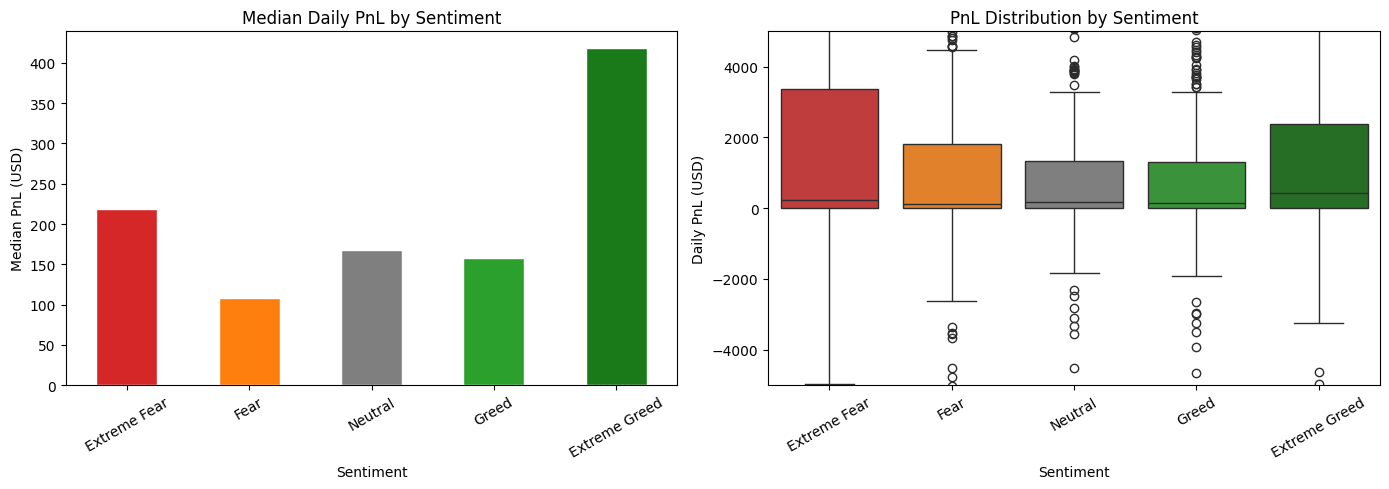

                    median         mean           std
classification                                       
Extreme Fear    218.377399  4619.439053  29534.839183
Fear            107.892532  5328.818161  31659.771538
Neutral         167.551743  3438.618818  17447.863645
Greed           158.214922  3318.100730  30599.040173
Extreme Greed   418.319862  5161.922644  27496.863832


In [ ]:
#PnL by sentiment
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1 — Median daily PnL by sentiment
pnl_by_sentiment = daily.groupby('classification')['daily_pnl'].median().reindex(
    ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed'])

colors = ['#d62728', '#ff7f0e', '#7f7f7f', '#2ca02c', '#1a7a1a']

pnl_by_sentiment.plot(kind='bar', ax=axes[0], color=colors, edgecolor='white')
axes[0].set_title('Median Daily PnL by Sentiment')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Median PnL (USD)')
axes[0].tick_params(axis='x', rotation=30)
axes[0].axhline(0, color='white', linewidth=0.8, linestyle='--')

# Chart 2 — PnL distribution box plot
order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']
sns.boxplot(data=daily, x='classification', y='daily_pnl', order=order,
            palette=colors, ax=axes[1])
axes[1].set_title('PnL Distribution by Sentiment')
axes[1].set_xlabel('Sentiment')
axes[1].set_ylabel('Daily PnL (USD)')
axes[1].tick_params(axis='x', rotation=30)
axes[1].set_ylim(-5000, 5000)  # cap outliers for readability

plt.tight_layout()
plt.savefig('charts/pnl_by_sentiment.png', dpi=130)
plt.show()

# Print actual numbers
print(daily.groupby('classification')['daily_pnl'].agg(['median', 'mean', 'std']).reindex(order))

 **INSIGHT:**

Panic creates opportunity for skilled traders, not average ones.
 
Extreme Fear days show the highest trade frequency (50.5 trades/day) and largest position sizes ($2,315 avg), but median PnL is still $218. Winning traders profit on fear days while Losing traders hit their lowest win rate (21%) on those same days. Same market, completely opposite outcomes depending on skill.

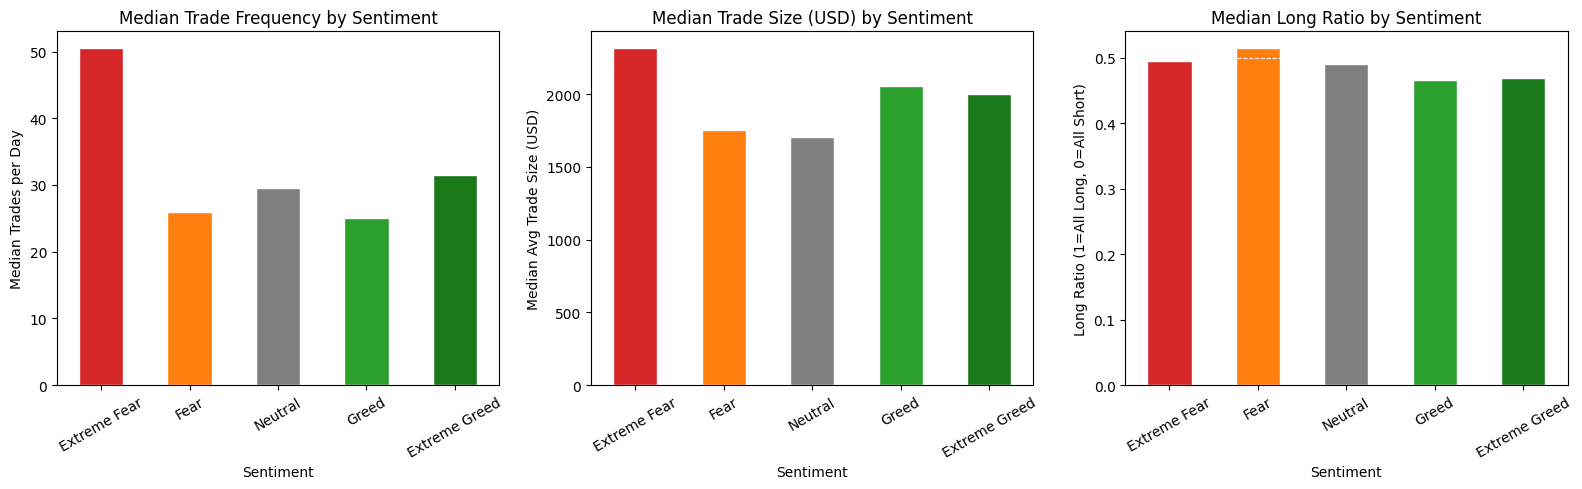

                trade_count  avg_trade_size  long_ratio
classification                                         
Extreme Fear           50.5        2315.630       0.495
Fear                   26.0        1752.677       0.514
Neutral                29.5        1704.405       0.490
Greed                  25.0        2052.535       0.465
Extreme Greed          31.5        2003.480       0.469


In [ ]:
#Behavior by sentiment
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']
colors = ['#d62728', '#ff7f0e', '#7f7f7f', '#2ca02c', '#1a7a1a']

# Chart 1 — Avg trade count by sentiment
trade_freq = daily.groupby('classification')['trade_count'].median().reindex(order)
trade_freq.plot(kind='bar', ax=axes[0], color=colors, edgecolor='white')
axes[0].set_title('Median Trade Frequency by Sentiment')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Median Trades per Day')
axes[0].tick_params(axis='x', rotation=30)

# Chart 2 — Avg trade size by sentiment
trade_size = daily.groupby('classification')['avg_trade_size'].median().reindex(order)
trade_size.plot(kind='bar', ax=axes[1], color=colors, edgecolor='white')
axes[1].set_title('Median Trade Size (USD) by Sentiment')
axes[1].set_xlabel('Sentiment')
axes[1].set_ylabel('Median Avg Trade Size (USD)')
axes[1].tick_params(axis='x', rotation=30)

# Chart 3 — Long ratio by sentiment
long_ratio = daily.groupby('classification')['long_ratio'].median().reindex(order)
long_ratio.plot(kind='bar', ax=axes[2], color=colors, edgecolor='white')
axes[2].set_title('Median Long Ratio by Sentiment')
axes[2].set_xlabel('Sentiment')
axes[2].set_ylabel('Long Ratio (1=All Long, 0=All Short)')
axes[2].tick_params(axis='x', rotation=30)
axes[2].axhline(0.5, color='white', linewidth=0.8, linestyle='--')

plt.tight_layout()
plt.savefig('charts/behavior_by_sentiment.png', dpi=130)
plt.show()

# Numbers
print(daily.groupby('classification')[['trade_count','avg_trade_size','long_ratio']].median().reindex(order).round(3))

**INSIGHT:**

Extreme Greed is the best environment across the board

Highest median PnL ($418), Winning traders at 100% win rate, Neutral traders finally cross 50% win rate. Rising tide lifts skilled boats the most.

C:\Users\Priyanshu\AppData\Local\Temp\ipykernel_15876\26373565.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  seg_pnl = daily.groupby(['classification', 'perf_segment'])['daily_pnl'].median().unstack()
C:\Users\Priyanshu\AppData\Local\Temp\ipykernel_15876\26373565.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  seg_size = daily.groupby(['classification', 'size_segment'])['avg_trade_size'].median().unstack()
C:\Users\Priyanshu\AppData\Local\Temp\ipykernel_15876\26373565.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass ob

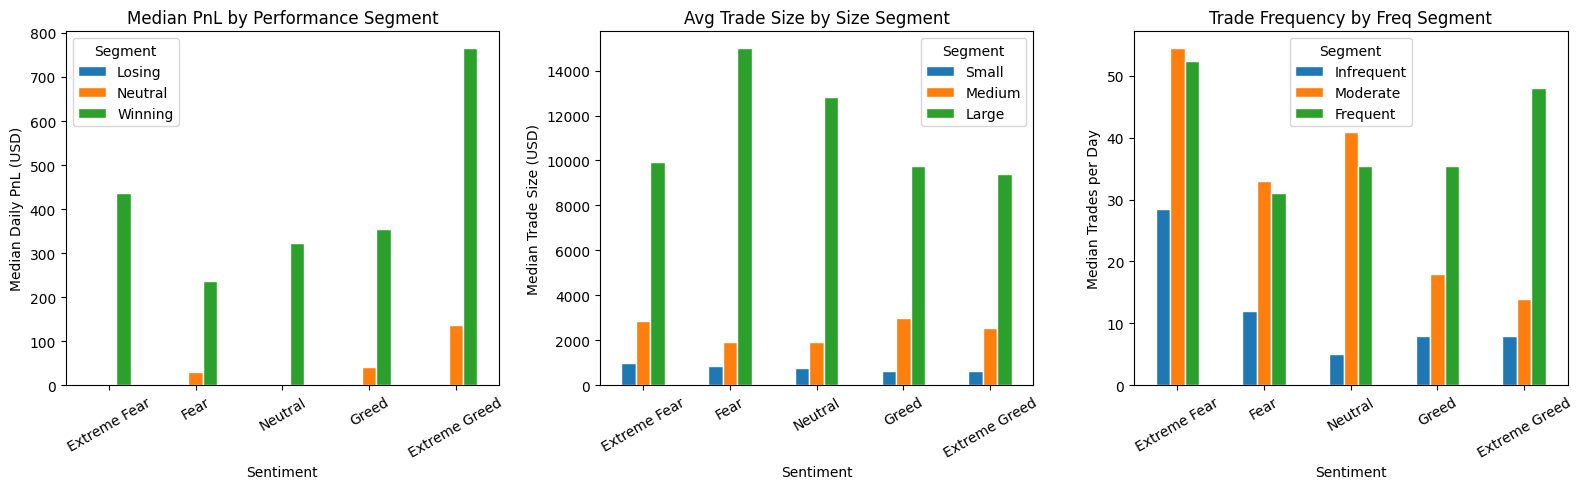

In [ ]:
#Segment analysis
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']

# Chart 1 — PnL by performance segment
seg_pnl = daily.groupby(['classification', 'perf_segment'])['daily_pnl'].median().unstack()
seg_pnl.reindex(order).plot(kind='bar', ax=axes[0], edgecolor='white')
axes[0].set_title('Median PnL by Performance Segment')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Median Daily PnL (USD)')
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend(title='Segment')

# Chart 2 — Trade size by size segment
seg_size = daily.groupby(['classification', 'size_segment'])['avg_trade_size'].median().unstack()
seg_size.reindex(order).plot(kind='bar', ax=axes[1], edgecolor='white')
axes[1].set_title('Avg Trade Size by Size Segment')
axes[1].set_xlabel('Sentiment')
axes[1].set_ylabel('Median Trade Size (USD)')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(title='Segment')

# Chart 3 — Trade frequency by freq segment
seg_freq = daily.groupby(['classification', 'freq_segment'])['trade_count'].median().unstack()
seg_freq.reindex(order).plot(kind='bar', ax=axes[2], edgecolor='white')
axes[2].set_title('Trade Frequency by Freq Segment')
axes[2].set_xlabel('Sentiment')
axes[2].set_ylabel('Median Trades per Day')
axes[2].tick_params(axis='x', rotation=30)
axes[2].legend(title='Segment')

plt.tight_layout()
plt.savefig('charts/segment_analysis.png', dpi=130)
plt.show()

**INSIGHT:**

Moderate traders overtrade during panic

Moderate frequency traders spike to 55 trades/day on Extreme Fear vs 18 on Extreme Greed. More activity, smaller trades, worse outcomes, classic stress-driven overtrading.


C:\Users\Priyanshu\AppData\Local\Temp\ipykernel_15876\3701092796.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  wr = daily.groupby(['classification', 'perf_segment'])['win_rate'].median().unstack()


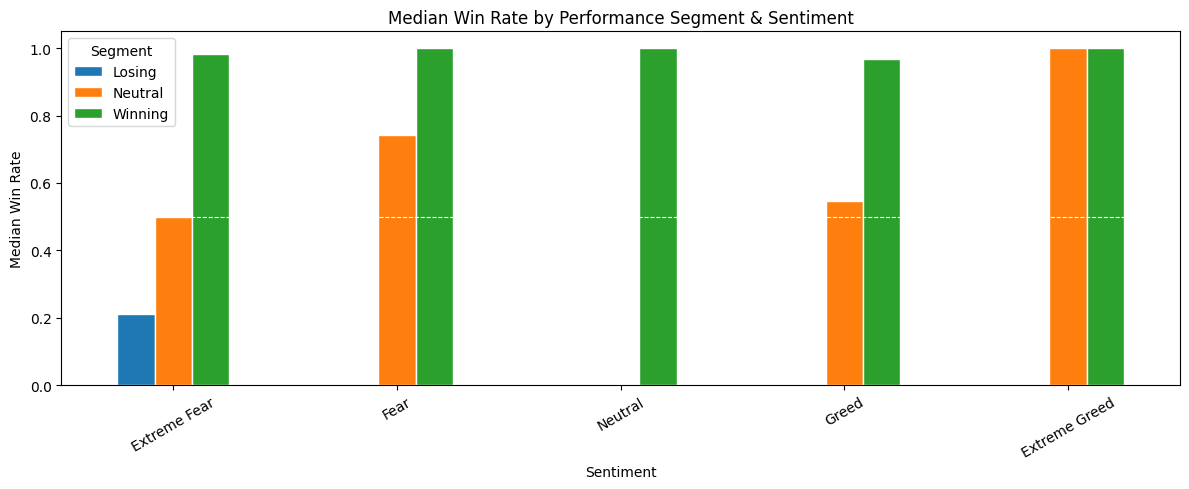

In [ ]:
#Win rate by segment
fig, ax = plt.subplots(figsize=(12, 5))

wr = daily.groupby(['classification', 'perf_segment'])['win_rate'].median().unstack()
wr.reindex(order).plot(kind='bar', ax=ax, edgecolor='white')
ax.set_title('Median Win Rate by Performance Segment & Sentiment')
ax.set_xlabel('Sentiment')
ax.set_ylabel('Median Win Rate')
ax.tick_params(axis='x', rotation=30)
ax.axhline(0.5, color='white', linewidth=0.8, linestyle='--')
ax.legend(title='Segment')

plt.tight_layout()
plt.savefig('charts/winrate_by_segment.png', dpi=130)
plt.show()

**Strategy 1:**

During Extreme Fear, Losing and Neutral segment traders should reduce trade frequency and size by at least 30%. The data shows these segments underperform most severely on panic days 

**Strategy 2:**

Winning segment traders should increase position sizes during Extreme Greed conditions. Their win rate holds at ~100% regardless of sentiment, but PnL peaks during Extreme Greed, suggesting their edge is amplified by bullish momentum.

